In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series

In [2]:
class WapePlusRbias:

    """Calculates as WAPE + Relative Bias."""

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:

        """Рассчитывает значение метрики."""

        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()

        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)

        return wape + rbias

In [3]:
df = pd.read_parquet("train_solo_track.parquet")
display(df.head())
display(df.tail())

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,471,2025-07-28 00:00:00,13,23,45,85645,491354,487,88655
1,471,2025-07-28 00:30:00,14,18,1,80049,494754,489,223929
2,471,2025-07-28 01:00:00,8,8,38,82616,490659,487,168519
3,471,2025-07-28 01:30:00,10,2,7,80506,489967,494,111380
4,471,2025-07-28 02:00:00,7,5,13,85992,479743,494,246046


,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
4629995,422,2025-11-01 08:30:00,18,12,13,94499,837543,103,129265
4629996,422,2025-11-01 09:00:00,13,25,5,97690,829459,104,50699
4629997,422,2025-11-01 09:30:00,11,20,35,93517,827038,104,210163
4629998,422,2025-11-01 10:00:00,17,19,24,101395,814070,104,328012
4629999,422,2025-11-01 10:30:00,16,18,16,104384,807239,106,227390


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4630000 entries, 0 to 4629999
Data columns (total 9 columns):
 #   Column     Dtype         
---  ------     -----         
 0   route_id   int64         
 1   timestamp  datetime64[ns]
 2   status_1   int64         
 3   status_2   int64         
 4   status_3   int64         
 5   status_4   int64         
 6   status_5   int64         
 7   status_6   int64         
 8   target_1h  int64         
dtypes: datetime64[ns](1), int64(8)
memory usage: 317.9 MB
None


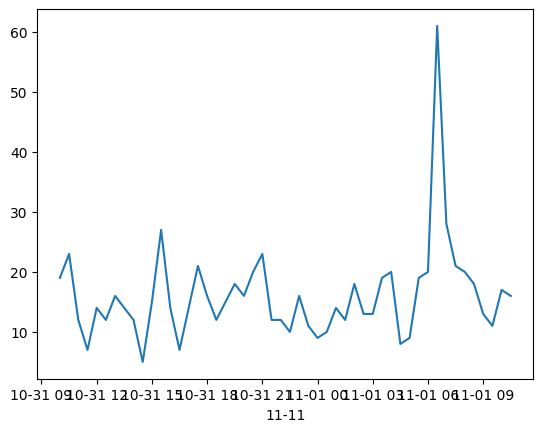

In [5]:
x = df["timestamp"][-50:].to_numpy()
y = df["status_1"][-50:].to_numpy()
plt.plot(x,y)
plt.xlabel(str(df["timestamp"][-20:].dt.month.min())+"-"+str(df["timestamp"][-20:].dt.month.max()))
plt.show()

In [6]:
df.tail()

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
4629995,422,2025-11-01 08:30:00,18,12,13,94499,837543,103,129265
4629996,422,2025-11-01 09:00:00,13,25,5,97690,829459,104,50699
4629997,422,2025-11-01 09:30:00,11,20,35,93517,827038,104,210163
4629998,422,2025-11-01 10:00:00,17,19,24,101395,814070,104,328012
4629999,422,2025-11-01 10:30:00,16,18,16,104384,807239,106,227390


C:\Users\sypna\AppData\Local\Temp\ipykernel_12540\3487334122.py:8: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(x,target_mean, label=["route_id", "mean"])


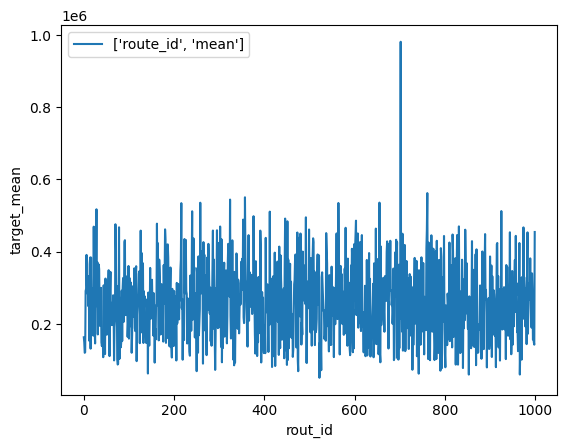

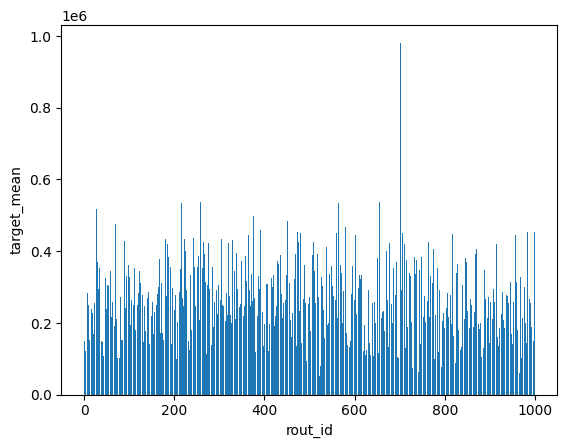

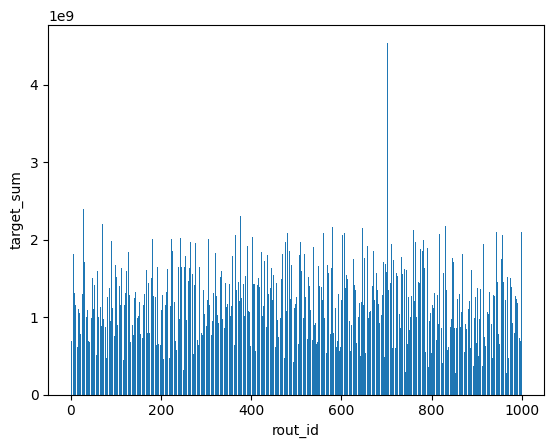

In [7]:
target_mean = df.groupby("route_id")["target_1h"].mean()
target_sum = df.groupby("route_id")["target_1h"].sum()
n = df.groupby("route_id").size()
# display(target_mean)
# display(target_sum)
# display(n)
x = np.unique(df["route_id"].to_numpy())
plt.plot(x,target_mean, label=["route_id", "mean"])
plt.xlabel("rout_id")
plt.ylabel("target_mean")
plt.legend()
plt.show()

plt.bar(x, target_mean)
plt.xlabel("rout_id")
plt.ylabel("target_mean")
plt.show()


plt.bar(x, target_sum)
plt.xlabel("rout_id")
plt.ylabel("target_sum")
plt.show()



In [8]:
def slot_to_hour(slot):
    return (30*slot)//60

In [9]:
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.dayofweek
minute = df["timestamp"].dt.minute
df["slot_in_day"] = df["hour"] * 2+ (minute // 30)

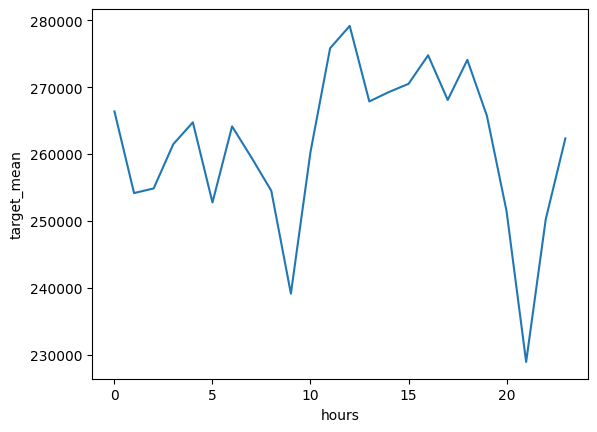

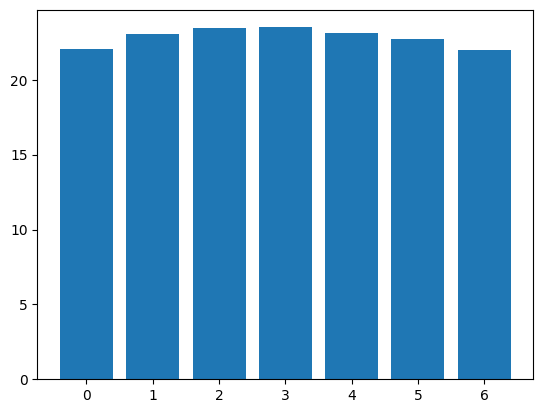

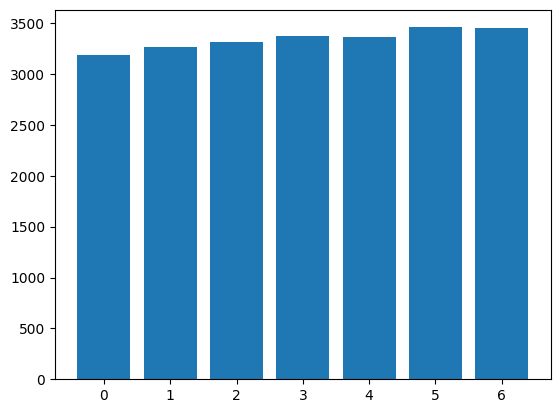

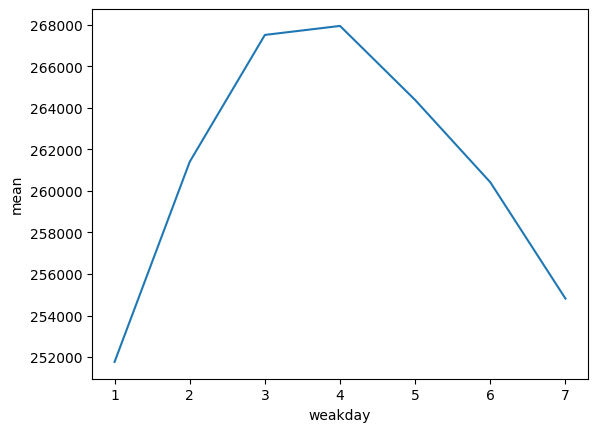

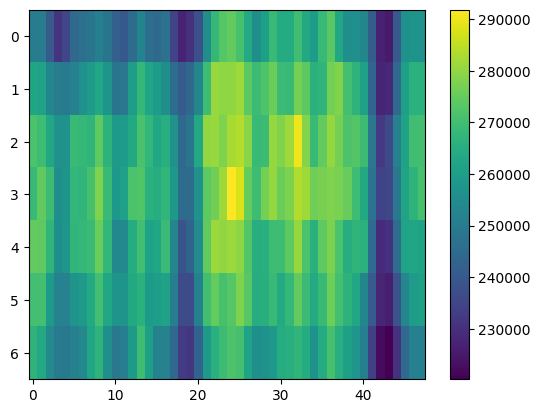

In [10]:
mean_hour_tg = df.groupby("hour")["target_1h"].mean()
plt.plot(mean_hour_tg.index,mean_hour_tg.values)
plt.xlabel("hours")
plt.ylabel("target_mean")
plt.show()

mean_for_status2 = df.groupby("weekday")["status_2"].mean()
plt.bar(df["weekday"].unique(), mean_for_status2)
plt.show()

"все статусы в середине недели растут кроме 6"
"6 статус растет от первого дня недели к последнему"

mean_for_status6 = df.groupby("weekday")["status_6"].mean()
plt.bar(df["weekday"].unique(), mean_for_status6)
plt.show()

weakly_mean = df.groupby("weekday")["target_1h"].mean()
plt.plot(weakly_mean.index+1,weakly_mean.values)
plt.xlabel("weakday")
plt.ylabel("mean")
plt.show()

mean_week_hour = df.groupby(["weekday", "slot_in_day"])["target_1h"].mean().unstack()
plt.imshow(mean_week_hour, cmap="viridis", aspect="auto")
plt.colorbar()
plt.show()


In [11]:
num_df = df.drop(columns=["timestamp"], errors="ignore").select_dtypes(include="number")
corr_to_target = num_df.corr()["target_1h"].drop("target_1h")
print(corr_to_target)

route_id      -0.006189
status_1       0.487596
status_2       0.506527
status_3       0.450902
status_4       0.431177
status_5       0.369687
status_6       0.104460
hour          -0.001284
weekday        0.002366
slot_in_day   -0.001282
Name: target_1h, dtype: float64


In [12]:
df = df.sort_values(["route_id", "timestamp"])
lags = [1, 2 ,4 ,48, 96, 336]
for lag in lags:
    df[f"lag_{lag}"] = df.groupby("route_id")["target_1h"].shift(lag)
    print(f"corr lag{lag}: ",df["target_1h"].corr(df[f"lag_{lag}"]))
print("\n")
windows = [2, 4, 48]
for w in windows:
    df[f"roll_mean_{w}"] = (
        df.groupby("route_id")["target_1h"]
          .transform(lambda s: s.shift(1).rolling(w).mean())
    )
    df[f"roll_std_{w}"] = (
        df.groupby("route_id")["target_1h"]
        .transform(lambda s: s.shift(1).rolling(w).std())
    )
    print(f"corr roll_mean_{w}:", df["target_1h"].corr(df[f"roll_mean_{w}"]))
    print(f"roll_std_{w}: ",df[f"roll_std_{w}"], f"corr roll_std: ", df["target_1h"].corr(df[f"roll_std_{w}"]))


corr lag1:  0.6842652079305535
corr lag2:  0.38437143934686213
corr lag4:  0.4347057985505833
corr lag48:  0.4971214508670107
corr lag96:  0.4888122893862326
corr lag336:  0.48035854844167525


corr roll_mean_2: 0.582257849674482
roll_std_2:  2268700              NaN
2268701              NaN
2268702     67127.060952
2268703     63032.205582
2268704     71909.931220
               ...      
2111275     56703.599890
2111276    395972.019290
2111277     76979.886841
2111278    273042.212487
2111279    161102.966385
Name: roll_std_2, Length: 4630000, dtype: float64 corr roll_std:  0.34479373160726384
corr roll_mean_4: 0.5925198571605583
roll_std_4:  2268700              NaN
2268701              NaN
2268702              NaN
2268703              NaN
2268704     75347.387924
               ...      
2111275    175355.238658
2111276    296431.113027
2111277    319831.601873
2111278    277985.203013
2111279    336322.875055
Name: roll_std_4, Length: 4630000, dtype: float64 corr roll_std:  0.345

In [13]:
"""дропнул не особо влияющие фичи"""
df = df.drop(columns=["lag_2", "lag_4", "lag_96", "roll_mean_2", "roll_mean_4", "roll_std_2", "roll_std_4"])
df.tail(10)

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h,hour,weekday,slot_in_day,lag_1,lag_48,lag_336,roll_mean_48,roll_std_48
2111270,999,2025-11-01 06:00:00,33,27,19,104638,627848,304,695119,6,5,12,489170.0,453817.0,104714.0,411290.520833,197714.838700
2111271,999,2025-11-01 06:30:00,25,21,61,98049,626161,302,469473,6,5,13,695119.0,656118.0,611561.0,416317.645833,201843.706579
2111272,999,2025-11-01 07:00:00,35,28,51,94900,615844,313,248710,7,5,14,469473.0,432212.0,782100.0,412429.208333,198902.144925
2111273,999,2025-11-01 07:30:00,26,38,13,100437,598045,306,653480,7,5,15,248710.0,378564.0,442874.0,408606.250000,200272.584077
2111274,999,2025-11-01 08:00:00,33,36,30,92548,603474,295,573289,8,5,16,653480.0,223513.0,319978.0,414333.666667,203303.260067
2111275,999,2025-11-01 08:30:00,36,35,16,101735,583961,285,13300,8,5,17,573289.0,323233.0,155724.0,421620.666667,202585.394891
2111276,999,2025-11-01 09:00:00,27,42,31,104019,575723,291,122166,9,5,18,13300.0,296802.0,77217.0,415163.729167,210569.844901
2111277,999,2025-11-01 09:30:00,24,40,40,108512,556784,305,508306,9,5,19,122166.0,280135.0,269361.0,411525.479167,214136.901989
2111278,999,2025-11-01 10:00:00,15,35,37,108471,543625,312,736140,10,5,20,508306.0,272110.0,671325.0,416279.041667,213690.230532
2111279,999,2025-11-01 10:30:00,27,30,43,120196,524346,325,644614,10,5,21,736140.0,532156.0,563581.0,425946.333333,217491.775052


In [14]:
df_test = pd.read_parquet("test_solo_track.parquet")
df_test.info()
df_test.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         8000 non-null   int64         
 1   route_id   8000 non-null   int64         
 2   timestamp  8000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 187.6 KB


id           0
route_id     0
timestamp    0
dtype: int64

In [15]:
display(df.head())
display(df_test.head())

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h,hour,weekday,slot_in_day,lag_1,lag_48,lag_336,roll_mean_48,roll_std_48
2268700,0,2025-07-28 00:00:00,13,13,7,58053,136443,97,87359,0,0,0,NaN,NaN,NaN,NaN,NaN
2268701,0,2025-07-28 00:30:00,6,18,13,58867,134643,95,182291,0,0,1,87359.0,NaN,NaN,NaN,NaN
2268702,0,2025-07-28 01:00:00,7,8,27,54848,135534,96,271432,1,0,2,182291.0,NaN,NaN,NaN,NaN
2268703,0,2025-07-28 01:30:00,7,8,5,53086,136497,100,169736,1,0,3,271432.0,NaN,NaN,NaN,NaN
2268704,0,2025-07-28 02:00:00,1,6,0,57561,135314,101,38880,2,0,4,169736.0,NaN,NaN,NaN,NaN


,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
3,3,471,2025-11-01 12:30:00
4,4,471,2025-11-01 13:00:00


In [16]:
def _black_friday(year_series):
    year_series = pd.Series(year_series, index=year_series.index)
    nov30 = pd.to_datetime({
        "year": year_series,
        "month": 11,
        "day": 30
    })
    shift = (nov30.dt.weekday - 4) % 7   # 4 = Friday
    return nov30 - pd.to_timedelta(shift, unit="D")


def add_train_marketplace_features(df):
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"])
    date = out["timestamp"].dt.normalize()
    year = out["timestamp"].dt.year

    sep1 = pd.to_datetime({"year": year, "month": 9, "day": 1})
    oct5 = pd.to_datetime({"year": year, "month": 10, "day": 5})
    nov11 = pd.to_datetime({"year": year, "month": 11, "day": 11})
    bf = _black_friday(year)

    distances = pd.concat([
        (sep1 - date).dt.days.abs(),
        (oct5 - date).dt.days.abs(),
        (nov11 - date).dt.days.abs(),
        (bf - date).dt.days.abs()
    ], axis=1)

    out["days_to_near_celebration"] = distances.min(axis=1)

    out["is_holiday"] = (
        ((date >= sep1 - pd.Timedelta(days=3)) & (date <= sep1 + pd.Timedelta(days=3))) |
        ((date >= oct5 - pd.Timedelta(days=3)) & (date <= oct5 + pd.Timedelta(days=3))) |
        ((date >= nov11 - pd.Timedelta(days=3)) & (date <= nov11 + pd.Timedelta(days=3))) |
        ((date >= bf - pd.Timedelta(days=3)) & (date <= bf + pd.Timedelta(days=3)))
    ).astype(int)

    return out


def add_test_november_features(X_df):
    out = X_df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"])
    date = out["timestamp"].dt.normalize()
    year = out["timestamp"].dt.year

    nov11 = pd.to_datetime({"year": year, "month": 11, "day": 11})
    bf = _black_friday(year)

    distances = pd.concat([
        (nov11 - date).dt.days.abs(),
        (bf - date).dt.days.abs()
    ], axis=1)

    out["days_to_near_celebration"] = distances.min(axis=1)

    out["is_holiday"] = (
        ((date >= nov11 - pd.Timedelta(days=3)) & (date <= nov11 + pd.Timedelta(days=3))) |
        ((date >= bf - pd.Timedelta(days=3)) & (date <= bf + pd.Timedelta(days=3)))
    ).astype(int)

    return out

In [17]:
train_model = add_train_marketplace_features(df)
X_df = add_test_november_features(df_test)

In [18]:
X_df["hour"] = X_df["timestamp"].dt.hour
X_df["weekday"] = X_df["timestamp"].dt.weekday
X_df["slot_in_day"] = X_df["timestamp"].dt.hour * 2 + X_df["timestamp"].dt.minute // 30
X_df["weekday"] = X_df["timestamp"].dt.weekday
X_df.drop(columns="id")

,route_id,timestamp,days_to_near_celebration,is_holiday,hour,weekday,slot_in_day
0,471,2025-11-01 11:00:00,10,0,11,5,22
1,471,2025-11-01 11:30:00,10,0,11,5,23
2,471,2025-11-01 12:00:00,10,0,12,5,24
3,471,2025-11-01 12:30:00,10,0,12,5,25
4,471,2025-11-01 13:00:00,10,0,13,5,26
...,...,...,...,...,...,...,...
7995,422,2025-11-01 12:30:00,10,0,12,5,25
7996,422,2025-11-01 13:00:00,10,0,13,5,26
7997,422,2025-11-01 13:30:00,10,0,13,5,27
7998,422,2025-11-01 14:00:00,10,0,14,5,28


In [19]:
display(X_df["hour"].max())
display(X_df["hour"].min())

np.int32(14)

np.int32(11)

In [20]:
lags = [1,2,3,4,8,48]
for lag in lags:
    train_model[f"lag_{lag}"] = train_model.groupby("route_id")["target_1h"].shift(lag)

train_model["roll_mean_4"] = (
    train_model.groupby("route_id")["target_1h"]
    .shift(1)
    .rolling(4)
    .mean()
    .reset_index(level=0, drop=True)
)

train_model["roll_mean_8"] = (
    train_model.groupby("route_id")["target_1h"]
    .shift(1)
    .rolling(8)
    .mean()
    .reset_index(level=0, drop=True)
)

In [21]:
columns = [
    "route_id",
    "timestamp",
    "days_to_near_celebration",
    "is_holiday",
    "hour",
    "slot_in_day",
    "weekday",
    "target_1h",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_8",
    "lag_48",
    "roll_mean_4",
    "roll_mean_8",
]
train_model = train_model[columns].copy()

In [22]:
train_model = train_model.dropna(subset=columns + ["target_1h"]).copy()

In [23]:
display(X_df.head())
display(train_model.head())

,id,route_id,timestamp,days_to_near_celebration,is_holiday,hour,weekday,slot_in_day
0,0,471,2025-11-01 11:00:00,10,0,11,5,22
1,1,471,2025-11-01 11:30:00,10,0,11,5,23
2,2,471,2025-11-01 12:00:00,10,0,12,5,24
3,3,471,2025-11-01 12:30:00,10,0,12,5,25
4,4,471,2025-11-01 13:00:00,10,0,13,5,26


,route_id,timestamp,days_to_near_celebration,is_holiday,hour,slot_in_day,weekday,target_1h,lag_1,lag_2,lag_3,lag_4,lag_8,lag_48,roll_mean_4,roll_mean_8
2268748,0,2025-07-29 00:00:00,34,0,0,0,1,9518,46413.0,217932.0,179051.0,181076.0,38880.0,87359.0,369470.00,323863.750
2268749,0,2025-07-29 00:30:00,34,0,0,1,1,132152,9518.0,46413.0,217932.0,179051.0,60467.0,182291.0,356194.00,287724.125
2268750,0,2025-07-29 01:00:00,34,0,1,2,1,136202,132152.0,9518.0,46413.0,217932.0,60467.0,271432.0,334517.50,272870.250
2268751,0,2025-07-29 01:30:00,34,0,1,3,1,83795,136202.0,132152.0,9518.0,46413.0,219957.0,169736.0,322179.75,300033.750
2268752,0,2025-07-29 02:00:00,34,0,2,4,1,155521,83795.0,136202.0,132152.0,9518.0,181076.0,38880.0,287070.75,328270.375


In [ ]:
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from catboost import CatBoostRegressor
from sklearn.base import clone
from lightgbm import LGBMRegressor
from window_ops.rolling import rolling_mean, rolling_std
from sklearn.model_selection import train_test_split
from datetime import time

In [25]:
model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=2000,
    learning_rate=0.07,
    depth=6,
    l2_leaf_reg=11,
    random_strength=1,
    bagging_temperature=0.5,
    use_best_model=True,
    verbose=100,
)


In [ ]:
train_model = train_model.sort_values(["timestamp", "route_id"]).copy()

train_model = train_model[
    train_model["timestamp"].dt.time.between(time(11,0), time(14,30))
].sort_values(["route_id", "timestamp"])

train_model = train_model.groupby("route_id", group_keys=False).tail(100)

uniq = train_model["timestamp"].sort_values().unique()
train, valid = train_test_split(
    uniq,
    test_size=0.2,
    shuffle=False
)
train_part = train_model[train_model["timestamp"].isin(train)].copy()
valid_part = train_model[train_model["timestamp"].isin(valid)].copy()

feature_cols = [
    "route_id",
    "hour",
    "slot_in_day",
    "weekday",
    "days_to_near_celebration",
    "is_holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_8",
    "lag_48",
    "roll_mean_4",
    "roll_mean_8",
]

x_train = train_part[feature_cols]
y_train = train_part["target_1h"]

x_valid = valid_part[feature_cols]
y_valid = valid_part["target_1h"]

In [27]:
def simple_ts_cv_df_catboost(
    df,
    model,
    feature_cols,
    target_col="target_1h",
    time_col="timestamp",
    id_col="route_id",
    h=8,
    n_windows=3,
    cat_features=None,
):
    df = df.sort_values([time_col, id_col]).copy()
    unique_ts = np.array(sorted(df[time_col].unique()))
    model_name = type(model).__name__

    results = []

    for i in range(n_windows):
        valid_end = len(unique_ts) - i * h
        valid_start = valid_end - h

        if valid_start <= 0:
            break

        train_ts = unique_ts[:valid_start]
        valid_ts = unique_ts[valid_start:valid_end]

        train_part = df[df[time_col].isin(train_ts)].copy()
        valid_part = df[df[time_col].isin(valid_ts)].copy()

        if train_part.empty or valid_part.empty:
            continue

        X_train = train_part[feature_cols]
        y_train = train_part[target_col]

        X_valid = valid_part[feature_cols]
        y_valid = valid_part[target_col]

        cur_model = clone(model)

        fit_kwargs = {
            "eval_set": (X_valid, y_valid),
        }
        if cat_features is not None:
            fit_kwargs["cat_features"] = cat_features

        cur_model.fit(X_train, y_train, **fit_kwargs)

        y_pred = cur_model.predict(X_valid)

        fold_df = valid_part[[id_col, time_col, target_col]].copy()
        fold_df[model_name] = y_pred
        fold_df["fold"] = n_windows - i

        results.append(fold_df)

    cv_df = pd.concat(results, ignore_index=True)
    cv_df = cv_df.sort_values([time_col, id_col]).reset_index(drop=True)
    return cv_df

In [35]:
feature_cols = [
    "route_id",
    "hour",
    "slot_in_day",
    "weekday",
    "days_to_near_celebration",
    "is_holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_8",
    "lag_48",
    "roll_mean_4",
    "roll_mean_8",
]

cv_df = simple_ts_cv_df_catboost(
    df=train_model,
    model=model,
    feature_cols=feature_cols,
    target_col="target_1h",
    time_col="timestamp",
    id_col="route_id",
    h=8,
    n_windows=3,
)

0:	learn: 134495.8040288	test: 131167.3022018	best: 131167.3022018 (0)	total: 26.7ms	remaining: 53.3s
100:	learn: 84097.8282040	test: 81659.4572044	best: 81659.4572044 (100)	total: 653ms	remaining: 12.3s
200:	learn: 82054.9796190	test: 80358.2743569	best: 80358.2743569 (200)	total: 1.25s	remaining: 11.2s
300:	learn: 81006.7350719	test: 80223.0175778	best: 80167.4590446 (284)	total: 1.89s	remaining: 10.6s
400:	learn: 80289.8524589	test: 80292.1216132	best: 80167.4590446 (284)	total: 2.59s	remaining: 10.3s
500:	learn: 79696.2613460	test: 80336.5174569	best: 80167.4590446 (284)	total: 3.31s	remaining: 9.89s
600:	learn: 79182.9360195	test: 80328.7552135	best: 80167.4590446 (284)	total: 4s	remaining: 9.31s
700:	learn: 78716.6911566	test: 80360.8454249	best: 80167.4590446 (284)	total: 4.69s	remaining: 8.69s
800:	learn: 78307.9585412	test: 80383.6129193	best: 80167.4590446 (284)	total: 5.37s	remaining: 8.04s
900:	learn: 77923.7906554	test: 80395.1810148	best: 80167.4590446 (284)	total: 6.04s	

In [29]:

y_true = cv_df["target_1h"]
y_pred = cv_df["CatBoostRegressor"]
res = WapePlusRbias().calculate(y_true=y_true, y_pred=y_pred)
print(res)

0.5338224421722596


In [30]:
bias = (cv_df["CatBoostRegressor"] - cv_df["target_1h"]).mean()
targ_mean = cv_df["target_1h"].mean()
pred_mean = cv_df["CatBoostRegressor"].mean()
print(bias)
display(target_mean)
display(pred_mean)
display((cv_df["CatBoostRegressor"] - cv_df["target_1h"]).sum() / cv_df["target_1h"].sum())

-22386.733071515377


route_id
0      162908.232613
1      148608.726350
2      119929.329158
3      121335.106479
4      291074.670626
           ...      
995    156637.320302
996    164350.902592
997    149176.903456
998    142464.471058
999    454439.779914
Name: target_1h, Length: 1000, dtype: float64

np.float64(261485.19613681792)

np.float64(-0.07886208803367019)

In [31]:
k = cv_df["target_1h"].sum() / cv_df["CatBoostRegressor"].sum()
cv_df["pred_calibrated"] = cv_df["CatBoostRegressor"] * k

res_old = WapePlusRbias().calculate(
    y_true=cv_df["target_1h"],
    y_pred=cv_df["CatBoostRegressor"]
)

res_new = WapePlusRbias().calculate(
    y_true=cv_df["target_1h"],
    y_pred=cv_df["pred_calibrated"]
)

print("k =", k)
print("old =", res_old)
print("new =", res_new)

k = 1.0856137685890328
old = 0.5338224421722596
new = 0.46010034617889434


In [37]:
X_test = X_df[feature_cols].copy()
X_test["route_id"] = X_test["route_id"].astype(str)   # если на train тоже было str

from catboost import Pool
test_pool = Pool(X_test, cat_features=["route_id"])

preds = model.predict(test_pool)

submission = pd.DataFrame({
    "id": X_df["id"].values,
    "y_pred": preds
})
submission.to_csv("submission_solo.csv", index=False)

KeyError: "['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'lag_48', 'roll_mean_4', 'roll_mean_8'] not in index"

In [ ]:
submission_path =  f"submission_solo.csv"
joined_path =  f"test_with_forecast_solo.csv"
preds.to_csv(submission_path, index=False)
print("submission saved to:", submission_path)

submission saved to: submission_solo.csv


итоговый скор по метрике 0.37